<div align="center">

# **ABCD fringe tracking**

</div>

✅ BMC lib found. Running in control mode.
DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Archive created at /mnt/disk1/archive/2026-02-02_e876d12/3_ABCD_fringe_tracking
Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:   0%|          | 0/4 [00:00<?, ?it/s]

Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:  25%|██▌       | 1/4 [00:08<00:26,  8.99s/it]

Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:  50%|█████     | 2/4 [00:17<00:17,  8.97s/it]

Turned off injection segments: [138, 137, 136, 135]


Calibrating injection:  75%|███████▌  | 3/4 [00:26<00:08,  8.99s/it]

Turned off injection segments: [138, 137, 136, 135]


Calibrating injection: 100%|██████████| 4/4 [00:36<00:00,  9.00s/it]


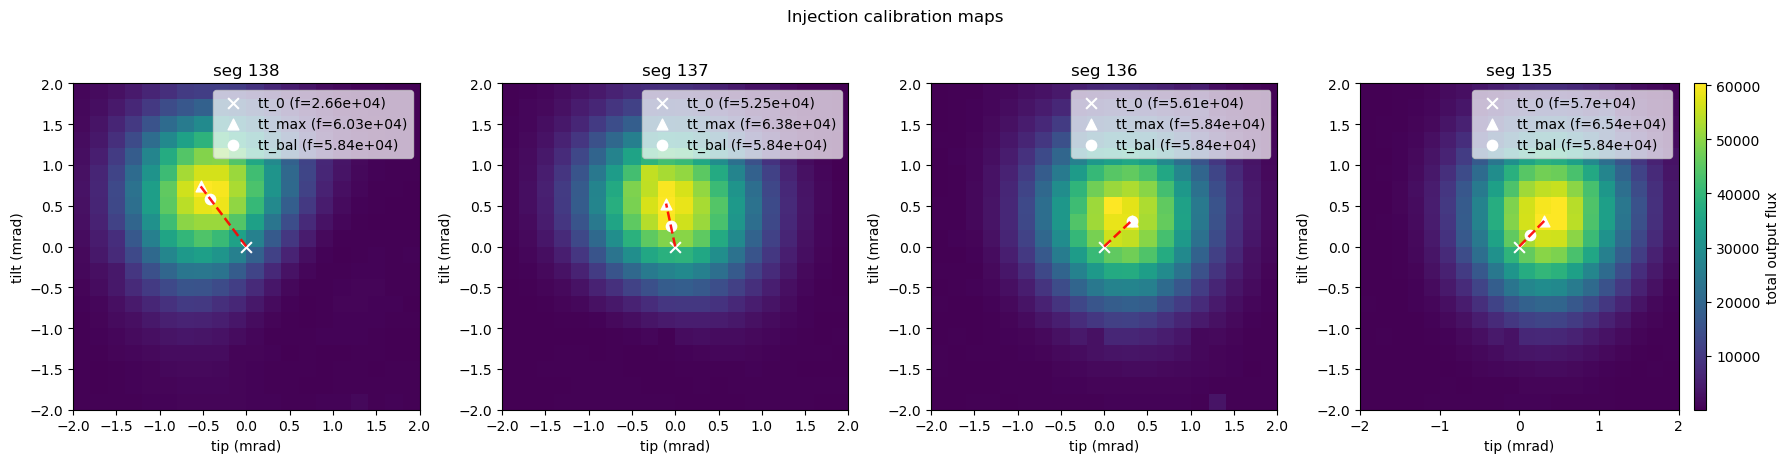

✅ Injection calibration saved to config under dm.ptt_max and dm.ptt_balanced
Applied BALANCED injection calibration on segments: [138, 137, 136, 135]


In [1]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import json

# Constants
lam = 1550 # [nm]

# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
inj_seg = phobos.Config().get('dm.injection_segments')

# Setup
path = phobos.archive.new('ABCD_fringe_tracking', verbose=True)
chip.phase_calibration(plot=True)
phobos.XPOW().turn_off()
dm_calib = dm.calibrate_injection(plot=True)
dm.balanced()

# Save DM calibration
dm_calib['figure'].savefig(path / 'DM_injection_calibration.png')

# 1. Pair scan

For each pair of telescopes, we scan in piston and look at the outputs response to identify the ABCD outputs.

Turned off injection segments: [138, 137, 136, 135]
Applied BALANCED injection calibration on segments: [138, 137]
Applied BALANCED injection calibration on segments: [138, 137]
Turned off injection segments: [138, 137, 136, 135]
Applied BALANCED injection calibration on segments: [138, 136]
Applied BALANCED injection calibration on segments: [138, 136]
Turned off injection segments: [138, 137, 136, 135]
Applied BALANCED injection calibration on segments: [138, 135]
Applied BALANCED injection calibration on segments: [138, 135]
Turned off injection segments: [138, 137, 136, 135]
Applied BALANCED injection calibration on segments: [137, 136]
Applied BALANCED injection calibration on segments: [137, 136]
Turned off injection segments: [138, 137, 136, 135]
Applied BALANCED injection calibration on segments: [137, 135]
Applied BALANCED injection calibration on segments: [137, 135]
Turned off injection segments: [138, 137, 136, 135]
Applied BALANCED injection calibration on segments: [136, 

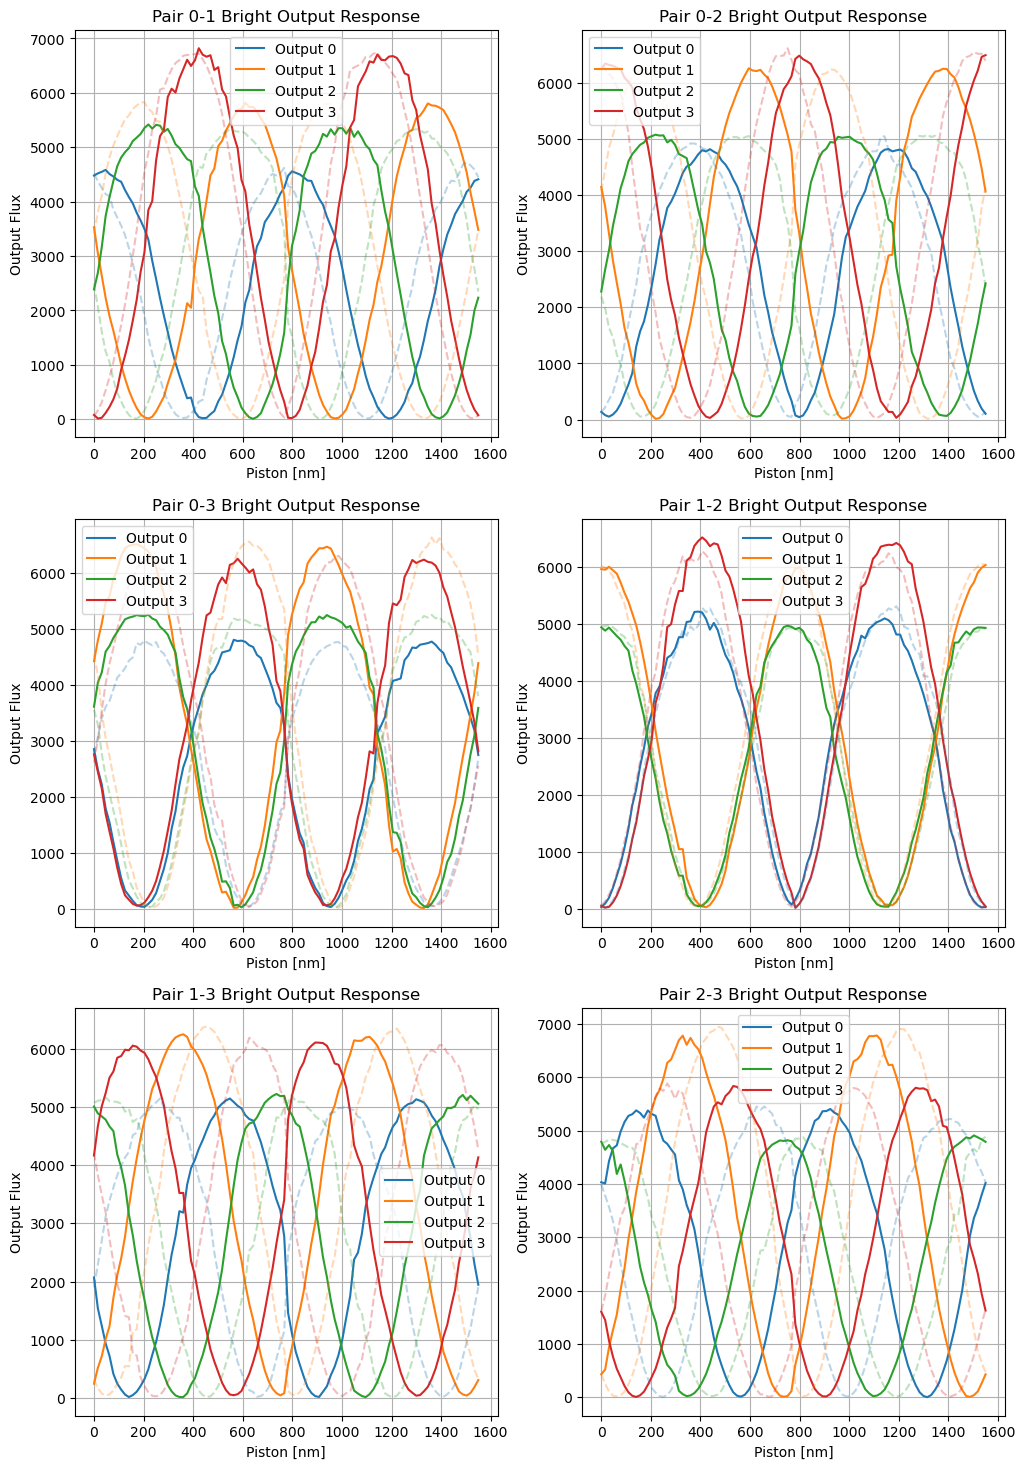

In [2]:
def pair_scan():
    pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
    piston_range = np.linspace(0, lam, 100)  # [nm]
    phase_range = (2 * np.pi / lam) * piston_range  # [rad]

    res = {}

    fig, axs = plt.subplots(3, 2, figsize=(12, 18))
    axs = axs.flatten()
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    for i, pair in enumerate(pairs):

        dm.off()
        dm.balanced(np.array(pair)+1)

        # Scan on first input
        outs = np.empty((len(phase_range), 4))
        for p, phase in enumerate(phase_range):
            dm[inj_seg[pair[0]]].set_phase(phase, lam=lam)
            outs[p] = cam.get_outputs(flux_mode='mean')

        res[pair] = outs.copy()

        for o in range(4):
            axs[i].plot(piston_range, outs[:, o], color=colors[o], label=f'Output {o}')

        # Scan on second input
        dm.balanced(np.array(pair)+1)
        outs = np.empty((len(phase_range), 4))
        for p, phase in enumerate(phase_range):
            dm[inj_seg[pair[1]]].set_phase(phase, lam=lam)
            outs[p] = cam.get_outputs(flux_mode='mean')

        res[(pair[1], pair[0])] = outs.copy()

        for o in range(4):
            axs[i].plot(piston_range, outs[:, o], color=colors[o], linestyle='--', alpha=0.3)
        
        axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
        axs[i].set_xlabel('Piston [nm]')
        axs[i].set_ylabel('Output Flux')
        axs[i].legend()
        axs[i].grid()

    return {'data': res, 'figure': fig}

res_pair_scan = pair_scan()
res_pair_scan['figure'].savefig(path / 'pair_scan.png')
with open(path / 'pair_scan_data.json', 'w') as f:
    json.dump({str(k): v.tolist() for k, v in res_pair_scan['data'].items()}, f)

# 2. Upstream piston RMS regimes

Applied BALANCED injection calibration on segments: [138, 137, 136, 135]
Scanning RMS=0 nm...
Scanning RMS=1 nm...
Scanning RMS=10 nm...
Scanning RMS=50 nm...
Scanning RMS=100 nm...
Scanning RMS=200 nm...


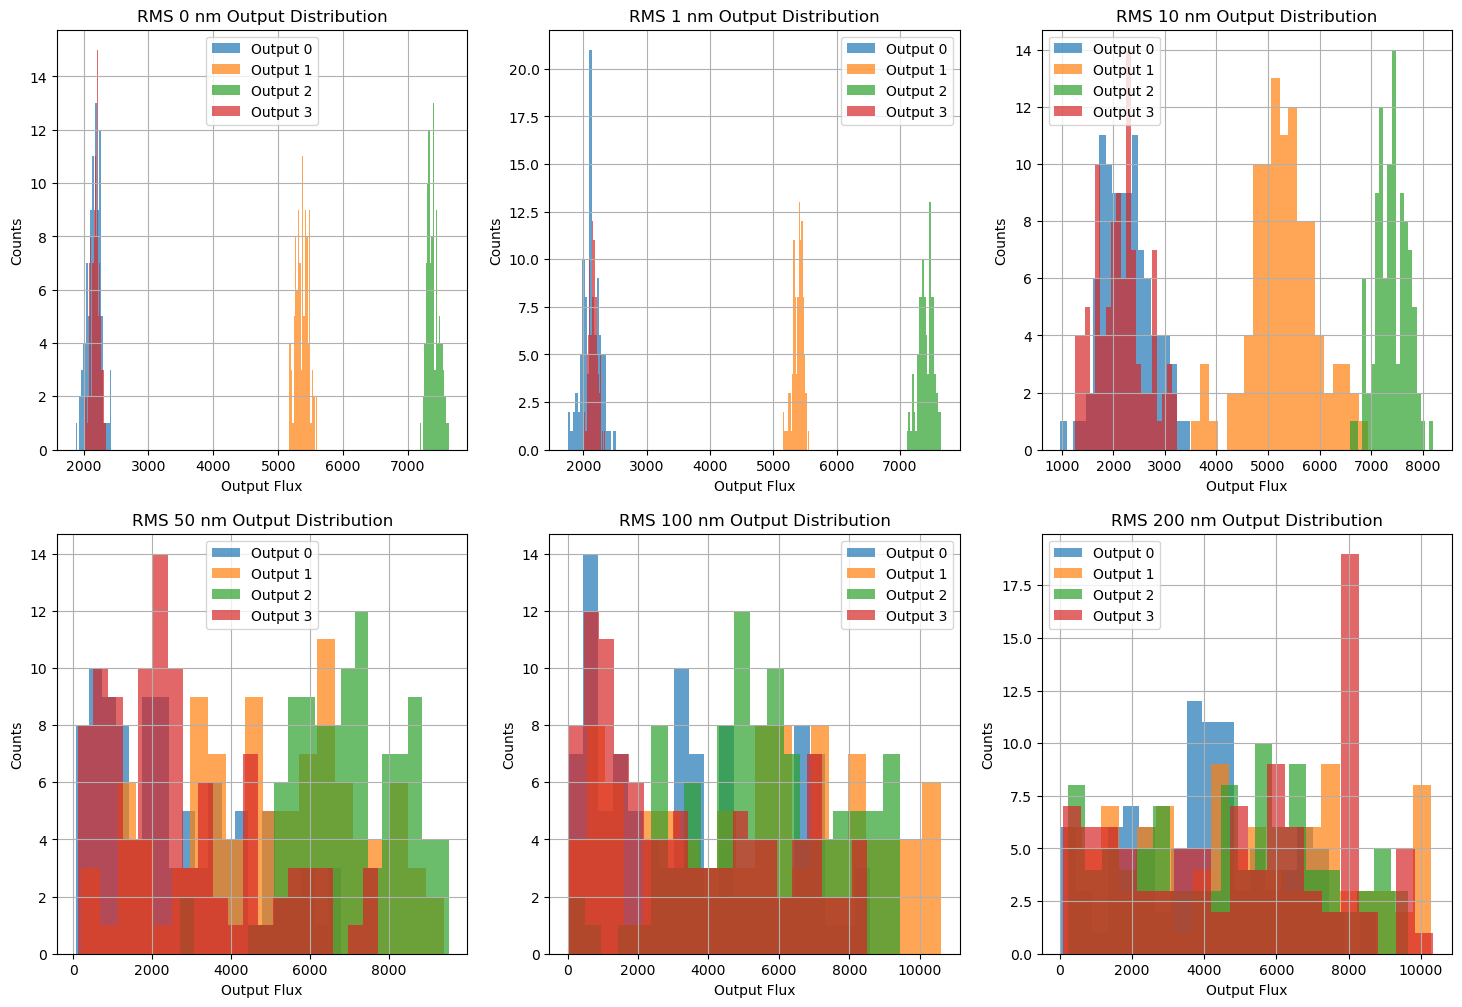

In [ ]:
rms_values = [0, 1, 10, 50, 100, 200] # [nm]

def rms_scan(n=100, correct_with_topas=False):

    dm.balanced()

    res = {}

    fig, axs = plt.subplots(2, 3, figsize=(18, 12))
    axs = axs.flatten()
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for i, rms in enumerate(rms_values):

        print(f'Scanning RMS={rms} nm...')

        outs = np.empty((n, 4))
        for p in range(n):
            pistons = np.random.normal(0, rms, size=4)  # [nm]
            phases = (2 * np.pi / lam) * pistons  # [rad]
            for s in range(4):
                dm[inj_seg[s]].set_phase(phases[s], lam=lam)
            
            if correct_with_topas:
                chip.set_phases(-phases)
                
            outs[p] = cam.get_outputs(flux_mode='mean')
        res['rms'] = outs.copy()
        
        for o in range(4):
            axs[i].hist(outs[:, o], bins=20, color=colors[o], alpha=0.7, label=f'Output {o}')
        axs[i].set_title(f'RMS {rms} nm Output Distribution')
        axs[i].set_xlabel('Output Flux')
        axs[i].set_ylabel('Counts')
        axs[i].legend()
        axs[i].grid()

    return {'data': res, 'figure': fig}

In [ ]:
res_rms_scan = rms_scan()
res_rms_scan['figure'].savefig(path / 'rms_scan.png')
with open(path / 'rms_scan_data.json', 'w') as f:
    json.dump({str(k): v.tolist() for k, v in res_rms_scan['data'].items()}, f)

# 3. Same with TOPA correction

Applied BALANCED injection calibration on segments: [138, 137, 136, 135]
Scanning RMS=0 nm...
Scanning RMS=1 nm...


/home/photonics/Progs/repos/PHOBos/src/phobos/classes/photonic_chip/phase_shifter.py:156: RuntimeWarning: invalid value encountered in sqrt
  voltage = np.sqrt(power / self.power_dac_factor)


Scanning RMS=10 nm...
Scanning RMS=50 nm...
Scanning RMS=100 nm...
Scanning RMS=200 nm...


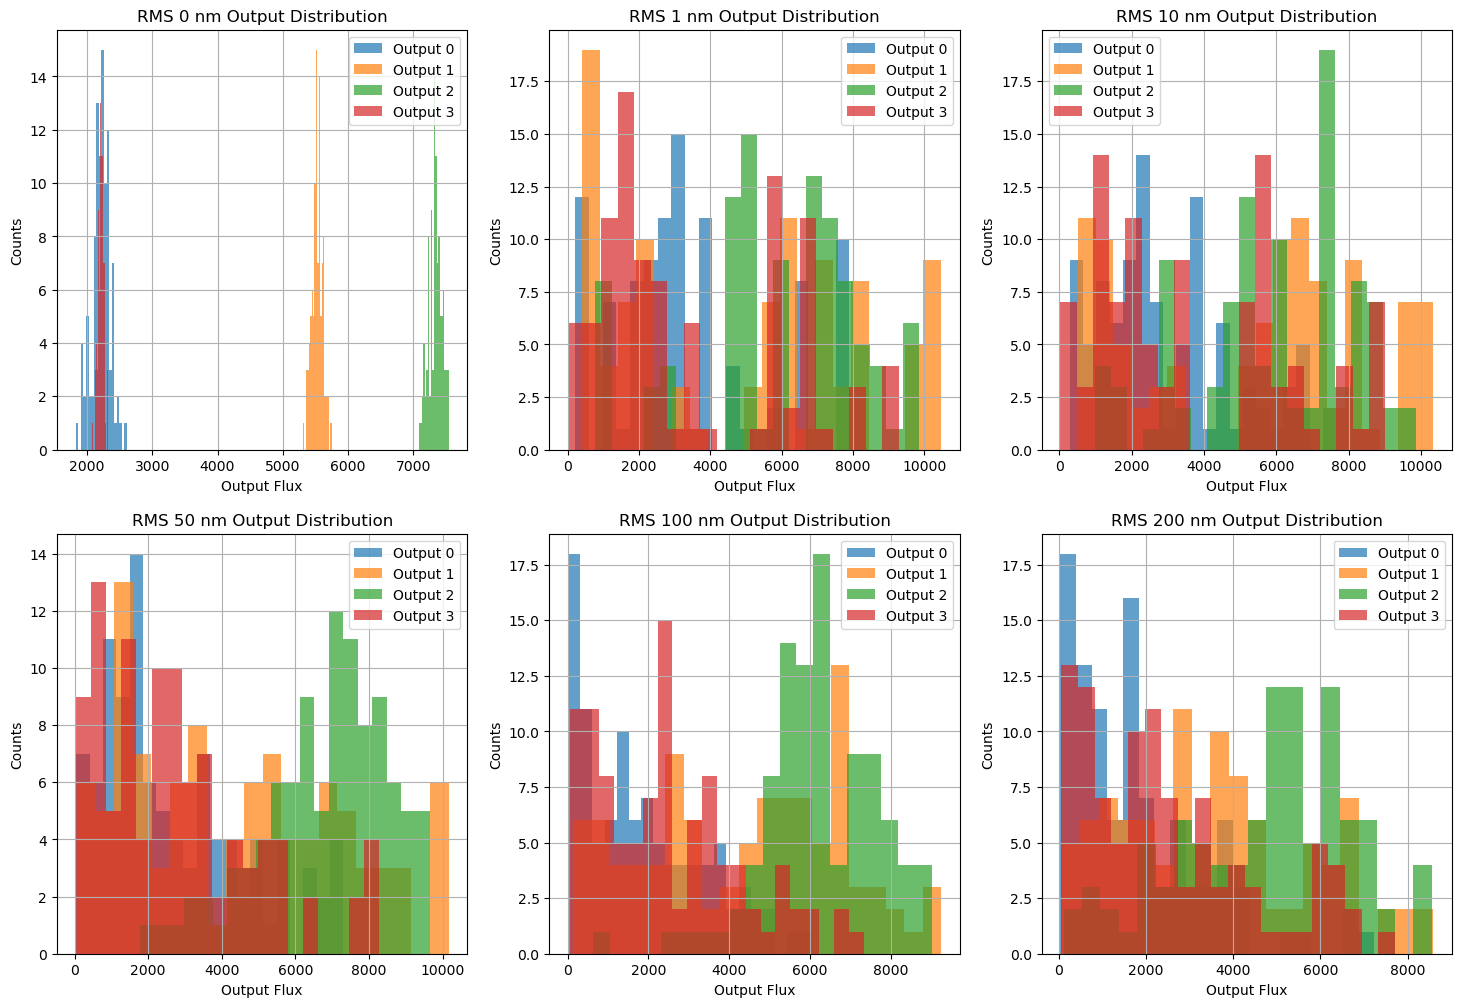

In [6]:
res_rms_scan_corrected = rms_scan(correct_with_topas=True)
res_rms_scan_corrected['figure'].savefig(path / 'rms_scan.png')
with open(path / 'rms_scan_data.json', 'w') as f:
    json.dump({str(k): v.tolist() for k, v in res_rms_scan_corrected['data'].items()}, f)

# The end.

In [5]:
phobos.XPOW().turn_off()
phobos.DM().zero()

Flattened injection segments: [138, 137, 136, 135]
